<a href="https://colab.research.google.com/github/Deveshjd/ML-Notebooks/blob/main/Customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing essetial libraries and data preprocessing.

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
df = pd.read_csv('/customer_churn_dataset-testing-master.csv')

In [107]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [108]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [111]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [112]:
df.nunique()

,0
CustomerID,64374
Age,48
Gender,2
Tenure,60
Usage Frequency,30
Support Calls,11
Payment Delay,31
Subscription Type,3
Contract Length,3
Total Spend,901


In [113]:
from scipy import sparse
# encoding categorical data (Gender, Subscription Type, Contract length )

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False)
encoded_array = encoder.fit_transform(df[["Gender", "Subscription Type", "Contract Length"]])
encoded_df = pd.DataFrame(encoded_array, columns = encoder.get_feature_names_out())
encoded_df.head()

,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [114]:
df = df.drop(["Gender", "Subscription Type", "Contract Length"], axis = 1).join(encoded_df) #Dropped old columns and added the encoded columns
df_cleaned = df.drop(["CustomerID"], axis = 1) # Dropped this column because customer id is just an arbitrary sequential no.
df.head()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,1,22,25,14,4,27,598,9,1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2,41,28,28,7,13,584,20,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,3,47,27,10,2,29,757,21,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,4,35,9,12,5,17,232,18,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,5,53,58,24,9,2,533,18,0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


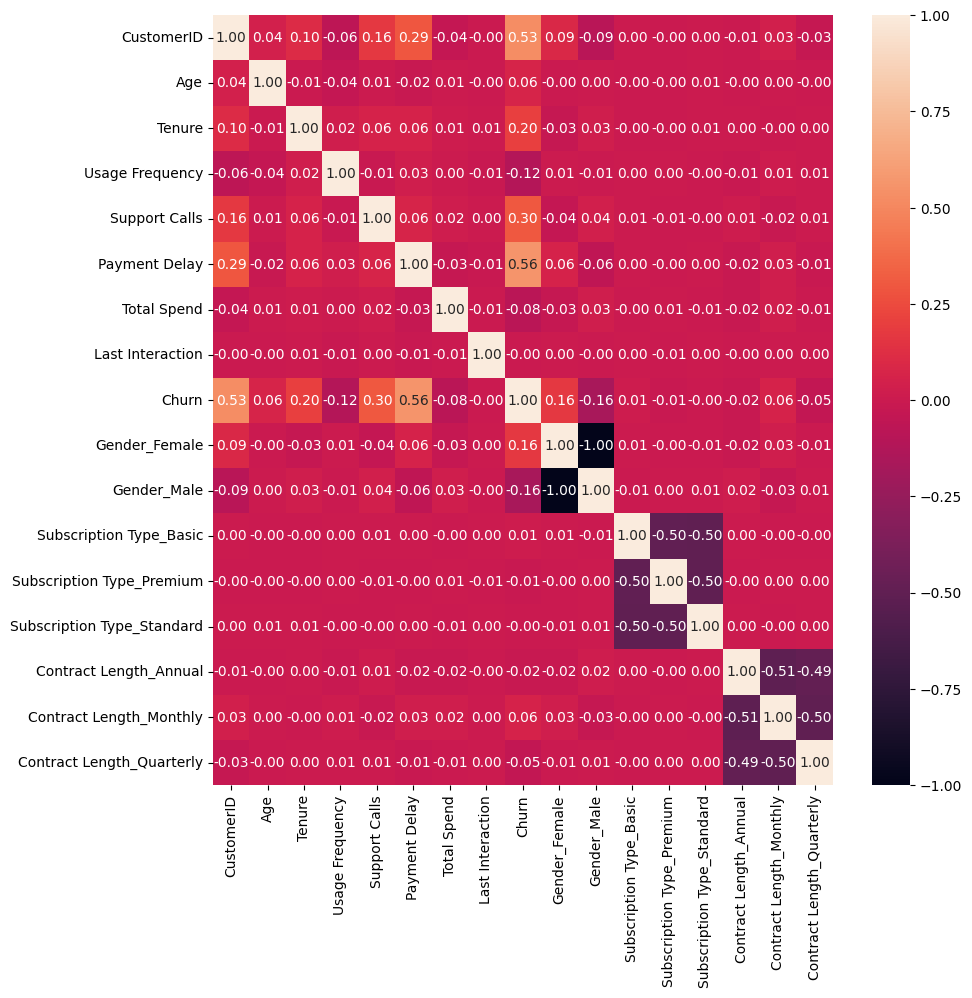

In [115]:
plt.figure(figsize = (10,10))
sns.heatmap(df.corr(), fmt = '.2f', annot = True)
plt.show()

***From the above correlation chart we can easily say that the features that impact the churn most are : 1. Payment delay(0.56), 2. Support calls(0.30), 3. Tenure(-0.20)***

# Model training

In [116]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [117]:
x = df_cleaned.drop("Churn", axis = 1)
y = df_cleaned["Churn"]

In [126]:
print(df[df["Churn"] == 1].shape)
print(df[df["Churn"] == 0].shape)

(30493, 17)
(33881, 17)


*The data is balanced*

In [143]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.4, random_state = 42)

In [144]:
DT = DecisionTreeClassifier()
RF = RandomForestClassifier()

In [145]:
DT.fit(x_train, y_train)

DecisionTreeClassifier()

In [146]:
RF.fit(x_train, y_train)

RandomForestClassifier()

In [147]:
y_pred_DT = DT.predict(x_test)
y_pred_RF = RF.predict(x_test)

# Model evaluation

In [148]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, classification_report

Accuracy Score :  0.9984466019417476
Recall Score :  0.9985192497532083
Precision Score :  0.9981907894736842
F1 Score :  0.9983549925974667


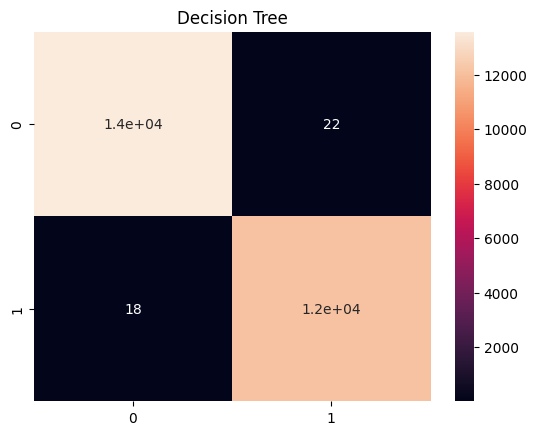

In [149]:
# For DT :
print("Accuracy Score : ", accuracy_score(y_test, y_pred_DT))
print("Recall Score : ", recall_score(y_test, y_pred_DT))
print("Precision Score : ", precision_score(y_test, y_pred_DT))
print("F1 Score : ", f1_score(y_test, y_pred_DT))

sns.heatmap(confusion_matrix(y_test, y_pred_DT), annot = True)
plt.title("Decision Tree")
plt.show()


In [152]:
print(classification_report(y_test, y_pred_DT))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13594
           1       1.00      1.00      1.00     12156

    accuracy                           1.00     25750
   macro avg       1.00      1.00      1.00     25750
weighted avg       1.00      1.00      1.00     25750



In [153]:
print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13594
           1       1.00      1.00      1.00     12156

    accuracy                           1.00     25750
   macro avg       1.00      1.00      1.00     25750
weighted avg       1.00      1.00      1.00     25750



Accuracy Score :  0.9980194174757282
Recall Score :  0.9965449160908193
Precision Score :  0.9992576095025983
F1 Score :  0.9978994192512047


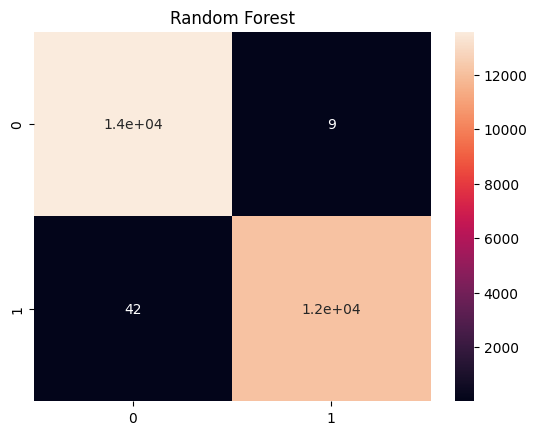

In [150]:
# For RF :
print("Accuracy Score : ", accuracy_score(y_test, y_pred_RF))
print("Recall Score : ", recall_score(y_test, y_pred_RF))
print("Precision Score : ", precision_score(y_test, y_pred_RF))
print("F1 Score : ", f1_score(y_test, y_pred_RF))

sns.heatmap(confusion_matrix(y_test, y_pred_RF), annot = True)
plt.title("Random Forest")
plt.show()


--- TOP 5 DOMINANT FEATURES ---
Payment Delay      0.430068
Support Calls      0.167837
Tenure             0.123662
Usage Frequency    0.083000
Total Spend        0.053596
dtype: float64


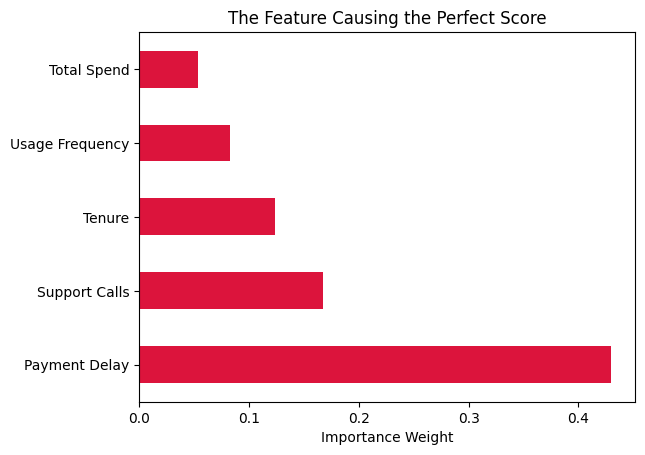

In [159]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract feature importances
importances = pd.Series(RF.feature_importances_, index=x_train.columns)

# 2. Sort and print the top 5
print("--- TOP 5 DOMINANT FEATURES ---")
print(importances.nlargest(5))

# 3. Plot them to visually confirm
importances.nlargest(5).plot(kind='barh', color='crimson')
plt.title("The Feature Causing the Perfect Score")
plt.xlabel("Importance Weight")
plt.show()


In [166]:
df_cleaned.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,41,28,28,7,13,584,20,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,47,27,10,2,29,757,21,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,35,9,12,5,17,232,18,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,53,58,24,9,2,533,18,0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [170]:
# 1. Drop the dominant leakage features along with CustomerID
X_realistic = df.drop(columns=[
    'CustomerID', 'Churn',
    'Payment Delay', 'Support Calls'  # The culprits!
])
y = df['Churn']

# 2. Re-split the data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_realistic, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Retrain the Random Forest
rf_realistic = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_realistic.fit(X_train_r, y_train_r)

# 4. Evaluate the new, realistic model
y_pred_realistic = rf_realistic.predict(X_test_r)
print(classification_report(y_test_r, y_pred_realistic))


              precision    recall  f1-score   support

           0       0.68      0.67      0.68      6776
           1       0.64      0.66      0.65      6099

    accuracy                           0.66     12875
   macro avg       0.66      0.66      0.66     12875
weighted avg       0.66      0.66      0.66     12875



In [171]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Initialize XGBoost with optimized baseline settings
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

# Train using your realistic datasets
xgb_model.fit(X_train_r, y_train_r)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test_r)
print(classification_report(y_test_r, y_pred_xgb))


              precision    recall  f1-score   support

           0       0.68      0.65      0.67      6776
           1       0.63      0.67      0.65      6099

    accuracy                           0.66     12875
   macro avg       0.66      0.66      0.66     12875
weighted avg       0.66      0.66      0.66     12875



# **After feature engineering**

In [162]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Copy your realistic feature set
df_engineered = X_realistic.copy()

# 1. Cost per interaction (High value, low activity = hidden churners)
df_engineered['Spend_Per_Usage'] = df_engineered['Total Spend'] / (df_engineered['Usage Frequency'] + 1)

# 2. Inactivity Ratio (How much of their tenure was spent inactive)
df_engineered['Inactivity_Ratio'] = df_engineered['Last Interaction'] / (df_engineered['Tenure'] + 1)

# 3. Usage Velocity (Are they an active user relative to their time with the company)
df_engineered['Usage_Intensity'] = df_engineered['Usage Frequency'] / (df_engineered['Tenure'] + 1)

print("New features added. Shape:", df_engineered.shape)


New features added. Shape: (64374, 16)


In [173]:
# Re-split with the engineered features
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    df_engineered, y, test_size=0.2, random_state=42, stratify=y
)

# Calculate scale_pos_weight (ratio of negative to positive cases)
ratio = 6776 / 6099

# Train highly tuned XGBoost
xgb_boosted = XGBClassifier(
    n_estimators=200,
    max_depth=4,            # Shallower trees prevent overfitting noisy data
    learning_rate=0.03,      # Slower learning rate prevents memorization
    scale_pos_weight=ratio,  # Forces model to focus on Class 1
    random_state=42
)

xgb_boosted.fit(X_train_e, y_train_e)

# Evaluate
y_pred_boosted = xgb_boosted.predict(X_test_e)
print(classification_report(y_test_e, y_pred_boosted))


              precision    recall  f1-score   support

           0       0.77      0.49      0.60      6776
           1       0.60      0.83      0.70      6099

    accuracy                           0.65     12875
   macro avg       0.68      0.66      0.65     12875
weighted avg       0.69      0.65      0.65     12875



/tmp/ipykernel_2538/1328218547.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


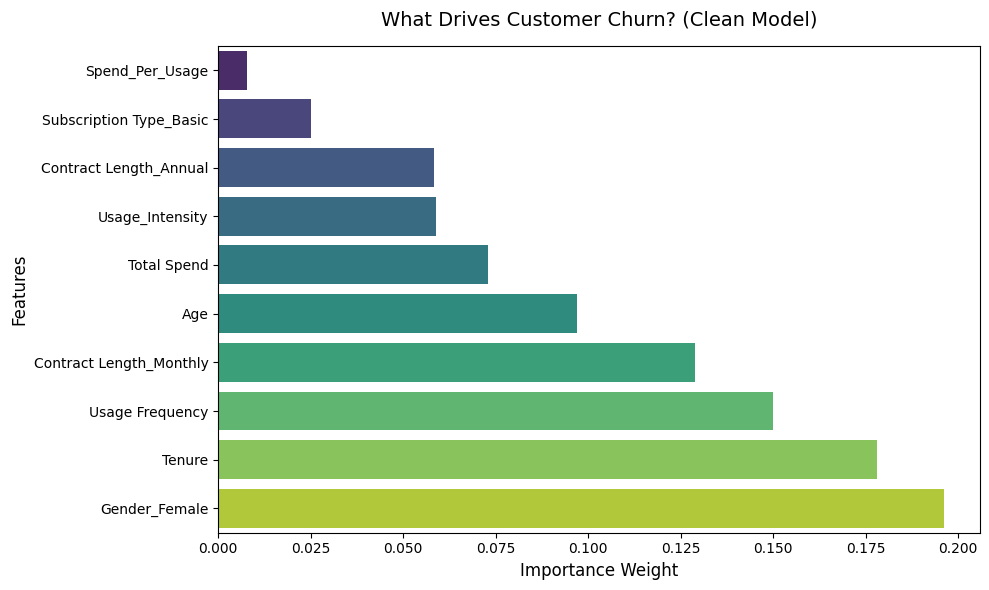

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract importances from your new XGBoost model
importances = pd.Series(xgb_boosted.feature_importances_, index=X_train_e.columns)
top_features = importances.nlargest(10).sort_values(ascending=True)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("What Drives Customer Churn? (Clean Model)", fontsize=14, pad=15)
plt.xlabel("Importance Weight", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()


In [165]:
# Calculate the literal churn percentage by gender
print(df.groupby('Gender_Female')['Churn'].mean())


Gender_Female
0.0    0.385797
1.0    0.550490
Name: Churn, dtype: float64
